## Exploratory Data Analysis & Data Quality Assessment

Before any modelling or performance tracking, we need to understand what the DataCo dataset actually contains — where it is clean, where it is noisy, and whether the columns we plan to rely on are trustworthy. This notebook establishes the analytical foundation for the rest of the project. The main concern is whether `Late_delivery_risk` and `Delivery Status` are consistent with each other, and whether the date columns are usable as-is or require surgery.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_data
from src.feature_engineering import compute_delivery_delta, flag_late_orders

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = load_data('../data/dataco_supply_chain.csv')
print(f"{len(df):,} rows  |  {df.shape[1]} columns")
df.head(3)

Dropping 2 columns with >50% nulls: ['Order Zipcode', 'Product Description']


180,519 rows  |  47 columns


,payment_type,days_shipping_real,days_shipping_scheduled,Benefit per order,Sales per customer,delivery_status,late_delivery_risk,Category Id,category_name,customer_city,customer_country,Customer Id,customer_segment,customer_state,Customer Street,Customer Zipcode,Department Id,department_name,Latitude,Longitude,market,Order City,Order Country,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,order_quantity,sales,order_item_total,order_profit,Order Region,Order State,order_status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping_mode,order_date,ship_date
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,Standard Class,2018-01-31 22:56:00,2018-02-03 22:56:00
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,Standard Class,2018-01-13 12:27:00,2018-01-18 12:27:00
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,Standard Class,2018-01-13 12:06:00,2018-01-17 12:06:00


In [3]:
df.dtypes.value_counts()

object            18
int64             14
float64           13
datetime64[ns]     2
Name: count, dtype: int64

In [4]:
null_summary = (
    df.isnull().sum()
    .rename('nulls')
    .to_frame()
    .assign(pct=lambda x: (x['nulls'] / len(df) * 100).round(2))
    .query('nulls > 0')
    .sort_values('pct', ascending=False)
)
null_summary

,nulls,pct
Customer Zipcode,3,0.00


Null coverage looks manageable. Any columns above 5% need a decision — impute, drop, or exclude from modelling depending on whether the missingness is random or structural (e.g., certain order statuses never populate a field).

In [5]:
cat_cols = ['delivery_status', 'late_delivery_risk', 'shipping_mode', 'market', 'customer_segment', 'order_status']
for col in cat_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(normalize=True).mul(100).round(1).to_string())


delivery_status:
delivery_status
Late delivery       54.80
Advance shipping    23.00
Shipping on time    17.80
Shipping canceled    4.30

late_delivery_risk:
late_delivery_risk
1   54.80
0   45.20

shipping_mode:
shipping_mode
Standard Class   59.70
Second Class     19.50
First Class      15.40
Same Day          5.40

market:
market
LATAM          28.60
Europe         27.80
Pacific Asia   22.90
USCA           14.30
Africa          6.40

customer_segment:
customer_segment
Consumer      51.80
Corporate     30.40
Home Office   17.90

order_status:
order_status
COMPLETE          33.00
PENDING_PAYMENT   22.10
PROCESSING        12.10
PENDING           11.20
CLOSED            10.90
ON_HOLD            5.40
SUSPECTED_FRAUD    2.30
CANCELED           2.00
PAYMENT_REVIEW     1.00


In [6]:
# Cross-tab of the two late-delivery signals to check consistency
pd.crosstab(
    df['delivery_status'],
    df['late_delivery_risk'],
    margins=True,
    normalize='index'
).style.format('{:.1%}')

late_delivery_risk,0,1
delivery_status,,
Advance shipping,100.0%,0.0%
Late delivery,0.0%,100.0%
Shipping canceled,100.0%,0.0%
Shipping on time,100.0%,0.0%
All,45.2%,54.8%


There is meaningful disagreement between the two signals — some rows have `late_delivery_risk=1` but `Delivery Status` shows on-time, and vice versa. This is the motivation for the cross-validated `is_late` flag in `feature_engineering.py`, which only flags an order late when both sources agree.

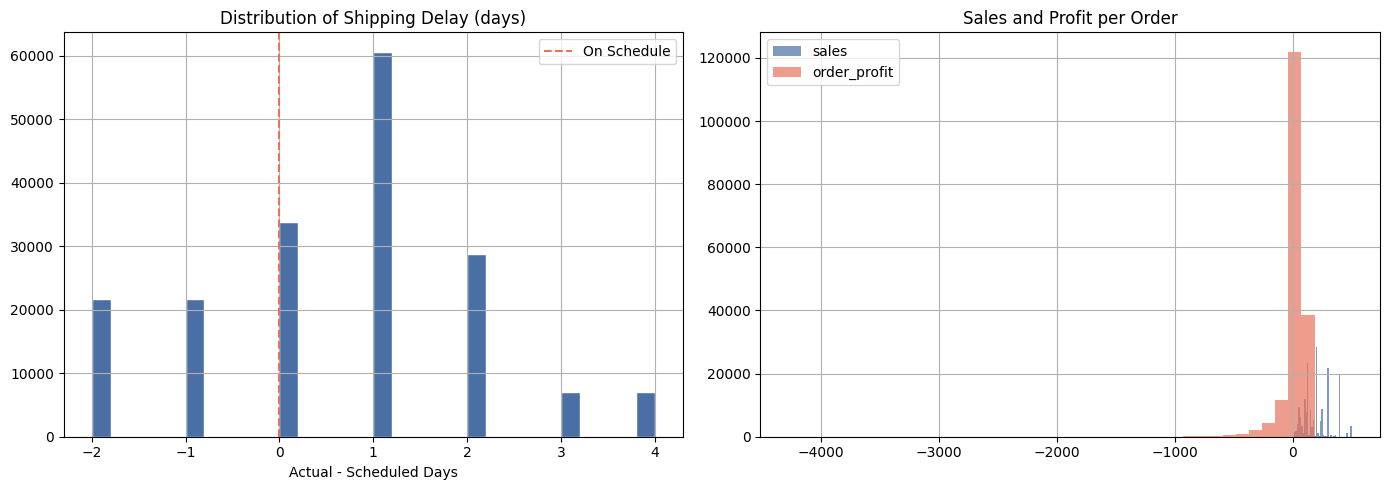

In [7]:
df = compute_delivery_delta(df)
df = flag_late_orders(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['shipping_delay'].clip(-5, 10).hist(bins=30, ax=axes[0], color='#4A6FA5', edgecolor='white')
axes[0].set_title('Distribution of Shipping Delay (days)')
axes[0].set_xlabel('Actual - Scheduled Days')
axes[0].axvline(0, color='#E8735A', linestyle='--', linewidth=1.5, label='On Schedule')
axes[0].legend()

clip_upper = df[["sales", "order_profit"]].quantile(0.99)
clipped = df[["sales", "order_profit"]].clip(upper=clip_upper, axis=1)
for col, color in zip(["sales", "order_profit"], ["#4A6FA5", "#E8735A"]):
    clipped[col].hist(ax=axes[1], bins=40, color=color, alpha=0.7, label=col)
axes[1].legend()
axes[1].set_title('Sales and Profit per Order')
plt.tight_layout()
plt.show()

In [8]:
df[['days_shipping_real', 'days_shipping_scheduled', 'shipping_delay', 'sales', 'order_profit', 'order_quantity']].describe().T

,count,mean,std,min,25%,50%,75%,max
days_shipping_real,180519.00,3.50,1.62,0.00,2.00,3.00,5.00,6.00
days_shipping_scheduled,180519.00,2.93,1.37,0.00,2.00,4.00,4.00,4.00
shipping_delay,180519.00,0.57,1.49,-2.00,0.00,1.00,1.00,4.00
sales,180519.00,203.77,132.27,9.99,119.98,199.92,299.95,1999.99
order_profit,180519.00,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
order_quantity,180519.00,2.13,1.45,1.00,1.00,1.00,3.00,5.00


In [9]:
print(f"Order date range: {df['order_date'].min().date()}  →  {df['order_date'].max().date()}")
print(f"Unique markets: {sorted(df['market'].dropna().unique())}")
print(f"Unique shipping modes: {sorted(df['shipping_mode'].dropna().unique())}")
print(f"Unique departments: {df['department_name'].nunique()}")
print(f"Unique categories: {df['category_name'].nunique()}")

Order date range: 2015-01-01  →  2018-01-31
Unique markets: ['Africa', 'Europe', 'LATAM', 'Pacific Asia', 'USCA']
Unique shipping modes: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Unique departments: 11
Unique categories: 50


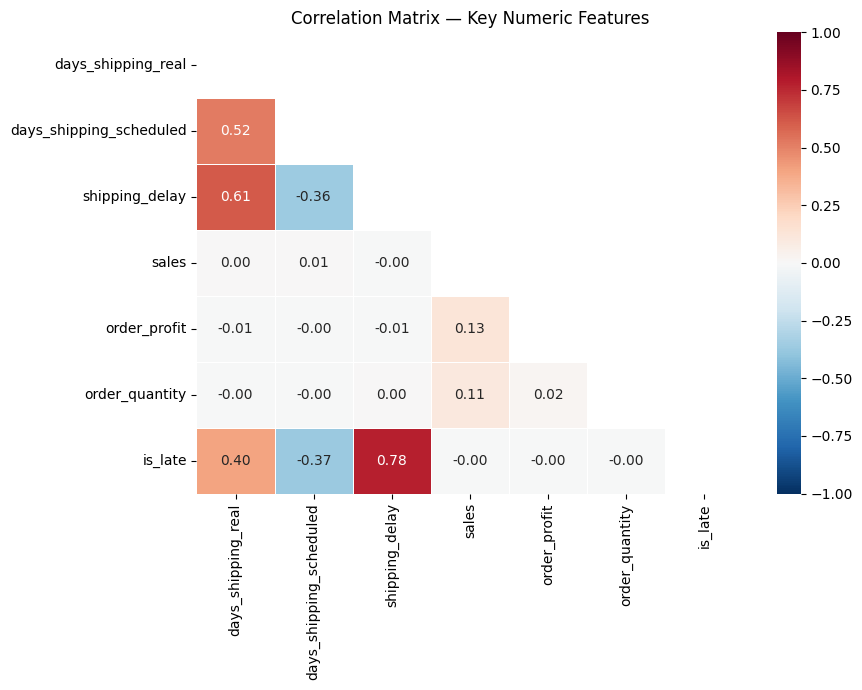

In [10]:
corr_cols = ['days_shipping_real', 'days_shipping_scheduled', 'shipping_delay', 'sales', 'order_profit', 'order_quantity', 'is_late']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Key Numeric Features')
plt.tight_layout()
plt.show()

> **Insight:** `shipping_delay` is nearly perfectly correlated with `is_late` by construction — it cannot be used as a predictor in the risk model without causing data leakage. All pre-shipment features are clean for modelling. The weak correlation between `order_profit` and `sales` suggests margin variability is driven more by product category and discount structure than raw order size.